# Data Selection

The data selected for this project comes from kaggle, created by Sarvesh Chhetri and available in the following link: 
https://www.kaggle.com/datasets/sarveshchhetri/student-lifestyle-vs-academic-performance-dataset?resource=download


This dataset captures a simulation of 8,000 university students with a wide variety of academic, behavioral and socioeconomic attributes.

The dataset has two versions: The one that classifies the target variable *grade* in a range from A-C, and the second one that has a numeric float value in the *grade* column.

This project will use the one that has the A-C classification (student_performance_grade.csv). So the model will be a classifier.


# Data Preprocessing

Data is preprocessed the following way:
- First, check for missing values
- Checking the distribution of the target variable is important to understand class balance
- Removal of information not important for the model (Student ID column)
- Encoding of the *grade* column so that string values can be transformed into their own, int classes
- Split the train and test sets with an 80/20 distribution
- Detect numeric and categorical columns
- One Hot Encoding for categorical columns
- Normalize numeric variables

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np



Missing values:
Student_ID                    0
Age                           0
Gender                        0
Hours_Studied                 0
Attendance                    0
Sleep_Hours                   0
Stress_Level                  0
Screen_Time                   0
Previous_GPA                  0
Part_Time_Job                 0
Study_Method                  0
Diet_Quality                  0
Internet_Quality              0
Extracurricular               0
Tutoring_Sessions_Per_Week    0
Family_Income_Level           0
Exam_Anxiety_Score            0
Grade                         0
dtype: int64

Grade distribution:
Grade
A       4475
B       2212
C       1053
D        226
Fail      34
Name: count, dtype: int64


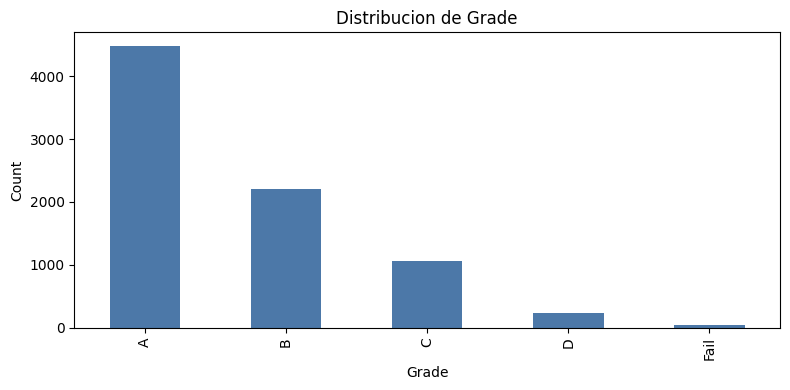

In [11]:
csv_path = 'student_performance_grade.csv'
df = pd.read_csv(csv_path)

# Check for missing values to see if some cleaning is needed before modeling
print('\nMissing values:')
print(df.isna().sum())

# Checking the distribution of the target variable 'Grade' to understand class balance
print('\nGrade distribution:')
print(df['Grade'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
df['Grade'].value_counts().sort_index().plot(kind='bar', color='#4c78a8')
plt.title('Distribucion de Grade')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



## Missing values and class balance

As shown, the dataset has no missing values, so further cleansing is not needed. However, the dataset proves to have a lot of class imbalances, since the grade 'A' has much more instances than 'Fail' for example.

In [12]:

# Remove the student ID, since it is not useful information and split features from the target variable
df_model = df.drop(columns=['Student_ID']).copy()
X = df_model.drop(columns=['Grade'])
y = df_model['Grade']

# Encode the target, so  the problem turns into a classification task with numeric labels.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split train and test sets, aiming to keep the class balance in both sets using stratification.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

# Search for numeric and categorical features to apply the appropriate transformations to each type.
numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

# Create the oneHotEncoder to transform categorical features
try:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse=False)

# Create the preprocessor to actually apply the transformations to the appropriate features
# Normalize the numeric data and one-hot encode the categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', one_hot, categorical_features),
    ]
)

# Preprocess the train set.
X_train_processed = preprocessor.fit_transform(X_train)

# Preprocess the test set, so just data transformation without fitting, to avoid data leakage.
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print('Train shape:', X_train_processed.shape, y_train.shape)
print('Test shape:', X_test_processed.shape, y_test.shape)
print('Processed features:')
display(X_train_processed.head())

Train shape: (6400, 29) (6400,)
Test shape: (1600, 29) (1600,)
Processed features:


,num__Age,num__Hours_Studied,num__Attendance,num__Sleep_Hours,num__Stress_Level,num__Screen_Time,num__Previous_GPA,num__Tutoring_Sessions_Per_Week,num__Exam_Anxiety_Score,cat__Gender_Female,...,cat__Diet_Quality_Poor,cat__Internet_Quality_Average,cat__Internet_Quality_Excellent,cat__Internet_Quality_Good,cat__Internet_Quality_Poor,cat__Extracurricular_No,cat__Extracurricular_Yes,cat__Family_Income_Level_High,cat__Family_Income_Level_Low,cat__Family_Income_Level_Middle
1352,1.527844,-0.263761,-0.664850,0.000955,-0.374323,0.454616,0.867377,0.262394,-0.064009,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
5964,-1.090615,-0.786194,-0.592392,1.341270,0.092153,-0.958666,-0.936209,1.162354,0.764535,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
6589,1.527844,-0.325224,0.484134,-0.836741,-0.529815,-0.622170,0.805891,0.262394,-0.359917,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4000,1.091434,0.437938,-1.772430,-0.836741,1.180597,-0.285674,0.027070,-1.537525,1.415533,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
6522,0.655024,2.179381,-0.571689,1.173731,-1.203613,0.118120,0.621433,0.262394,-0.655825,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


# Simple Model Implementation
This model implementation uses logisticRegression and scikit-learn.

In [ ]:
logreg = LogisticRegression()
logreg.fit(X_train_processed, y_train)

y_pred = logreg.predict(X_test_processed)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

try:
    if 'y_test' in globals() and 'y_pred' in globals():
        print('Accuracy:', accuracy_score(y_test, y_pred))

        precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
        recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
        f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)

        try:
            labels = label_encoder.classes_
        except NameError:
            labels = None

        if labels is not None:
            for lbl, p, r, f in zip(labels, precision_per_class, recall_per_class, f1_per_class):
                print(f"Class {lbl}: Precision={p:.3f}, Recall={r:.3f}, F1={f:.3f}")
        else:
            print('Precision per class:', precision_per_class)
            print('Recall per class:', recall_per_class)
            print('F1-score per class:', f1_per_class)
    else:
        print('`y_test` y `y_pred` not found.')
except Exception as e:
    print('Error:', e)


Accuracy: 0.7675
Class A: Precision=0.874, Recall=0.905, F1=0.889
Class B: Precision=0.629, Recall=0.647, F1=0.638
Class C: Precision=0.614, Recall=0.550, F1=0.580
Class D: Precision=0.556, Recall=0.333, F1=0.417
Class Fail: Precision=0.500, Recall=0.143, F1=0.222


c:\Users\dani-.DANIEL\Documents\Octavo\Student-Grade-Prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


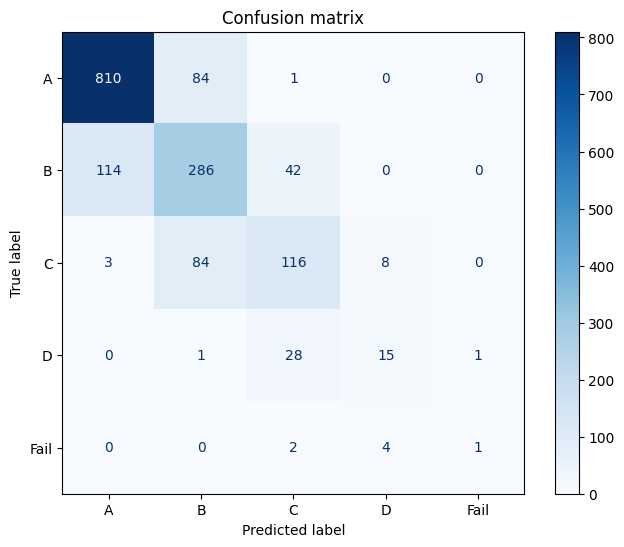

Classification report:
              precision    recall  f1-score   support

           A       0.87      0.91      0.89       895
           B       0.63      0.65      0.64       442
           C       0.61      0.55      0.58       211
           D       0.56      0.33      0.42        45
        Fail       0.50      0.14      0.22         7

    accuracy                           0.77      1600
   macro avg       0.63      0.52      0.55      1600
weighted avg       0.76      0.77      0.76      1600



In [5]:

try:
    labels = label_encoder.classes_
except NameError:
    labels = None

if 'y_test' in globals() and 'y_pred' in globals():
    if labels is not None:
        cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(labels)))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        fig, ax = plt.subplots(figsize=(8, 6))
        disp.plot(cmap='Blues', ax=ax, values_format='d')
        plt.title('Confusion matrix')
        plt.show()

        print('Classification report:')
        print(classification_report(y_test, y_pred, target_names=labels))
    else:
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        fig, ax = plt.subplots(figsize=(8, 6))
        disp.plot(cmap='Blues', ax=ax, values_format='d')
        plt.title('Confusion matrix')
        plt.show()

        print('Classification report:')
        print(classification_report(y_test, y_pred))
else:
    print('No se encontraron `y_test` y `y_pred`.')

# Conclusion and Result Interpretation

**Observations**:
- There is a majority class (grade A) which shows much higher precision/recall than the minority classes, the model is likely biased due to class imbalance.
- Certain classes are frequently confused with one another (e.g., Fail ↔ C), this may indicate that the current features do not sufficiently distinguish between those labels.

**Practical recommendations:**
- Address class imbalance for minority classes.
- Try non-linear models suggested by a state-of-the-art model
- Validation and tuning: research hyperparameter optimization.
- Interpretability: compute feature importances to understand why certain predictions are being made.


# Framework-based Model
The idea is to implement a model based on a framework from a state-of-the-art paper proposed by **Ma & Xiao (2026)** - [Application of deep learning to the development of a prediction model for college students’ learning outcomes](https://www.scopus.com/pages/publications/105027887338?origin=resultslist)

## Architecture Overview

The paper proposes a 3-stage pipeline:

| Stage | Component | Purpose |
|---|---|---|
| 1 | **ResNet blocks** | Hierarchical feature extraction from tabular data |
| 2 | **Autoencoder** | Dimensionality reduction: compress features into a latent space Z |
| 3 | **LSTM** | Feature selection: identify the most predictive features across the sequence |
| Optimization | **Cheetah Algorithm** | Hyperparameter tuning (simulated via a candidate search) |

### Adapting the paper to the classification task
The paper targets **regression** (continuous exam scores). Our problem is **multi-class classification** (grades A–F):

| Paper (Regression) | Adaptation (Classification) |
|---|---|
| MSE loss | Categorical Cross-Entropy loss |
| Linear output | Softmax output (one node per class) |
| RMSE / MAE / R² | Accuracy, Precision, Recall, F1, AUC-ROC |

## Imports

In [6]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## Data re-preprocessing for the framework

The paper uses **Min-Max Normalization** (Eq. 2) instead of StandardScaler, so the preprocessor was rebuilt using MinMax to match the paper exactly.
The train/test split and the label encoder from the baseline section are reused.

In [ ]:
# Rebuild the preprocessor with MinMaxScaler
try:
    one_hot_fw = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot_fw = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor_fw = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),  
        ('cat', one_hot_fw, categorical_features),   
    ]
)

X_train_fw = preprocessor_fw.fit_transform(X_train)
X_test_fw  = preprocessor_fw.transform(X_test)

input_dim = X_train_fw.shape[1]
n_classes = len(label_encoder.classes_)

print('Input dimension:', input_dim)
print('Number of classes:', n_classes, '→', label_encoder.classes_)

# ── Class imbalance fix 1: compute class weights ──────────────────────
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))
print('\nClass weights (mayor peso = clase más rara):')
for idx, w in class_weight_dict.items():
    print(f'  {label_encoder.classes_[idx]}: {w:.4f}')

# ── Class imbalance fix 2: SMOTE to create synthetic data for minority classes ─
# SMOTE generates synthetic examples by interpolating between real neighbors.
# It is only applied to the training set, NEVER to the test set.
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train_fw, y_train)
    print(f'\nSMOTE applied:')
    print(f'  Train before: {X_train_fw.shape[0]} samples')
    print(f'  Train after: {X_train_sm.shape[0]} samples')
    unique, counts = np.unique(y_train_sm, return_counts=True)
    for u, c in zip(unique, counts):
        print(f'  {label_encoder.classes_[u]}: {c}')
except ImportError:
    print('imbalanced-learn no instalado. Instalando...')
    import subprocess
    subprocess.run(['pip', 'install', 'imbalanced-learn', '-q'])
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train_fw, y_train)
    print(f'\nTrain after SMOTE: {X_train_sm.shape[0]} samples')


Input dimension: 29
Number of classes: 5 → ['A' 'B' 'C' 'D' 'Fail']

Class weights (mayor peso = clase más rara):
  A: 0.3575
  B: 0.7232
  C: 1.5202
  D: 7.0718
  Fail: 47.4074

SMOTE aplicado:
  Train antes: 6400 muestras
  Train después: 17900 muestras
  A: 3580
  B: 3580
  C: 3580
  D: 3580
  Fail: 3580


## Stage 1 — ResNet Encoder

ResNet uses **residual (skip) connections** that allow gradients to flow directly through layers, solving the vanishing gradient problem in deep networks.

The output of each block is the *learned transformation* **plus** the *original input*. The network only has to learn the **residual** (difference), which is much easier to optimize.
For tabular data, ResNet blocks are built with `Dense` layers instead of convolutions.

In [ ]:
def resnet_block(x, units, dropout_rate=0.2):
    shortcut = x
    x = layers.Dense(units)(x)
    x = layers.BatchNormalization()(x) 
    x = layers.Activation('relu')(x)  
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(units)(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != units:
        shortcut = layers.Dense(units)(shortcut)
    x = layers.Add()([x, shortcut])    
    x = layers.Activation('relu')(x)
    return x

print('ResNet block defined.')

ResNet block defined.


## Stage 2 — Autoencoder (Dimensionality Reduction)

The Autoencoder compresses the ResNet features into a **latent space Z**, removing noise and redundancy.

The autoencoder is pretrained in an **unsupervised** way, this is how it learns to reconstruct the input, forcing the latent space Z to capture the most essential information.

Model: "resnet_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ae_input            │ (None, 29)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      3,840 │ ae_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │      3,840 │ ae_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ batch_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128)       │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64)        │          0 │ batch_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64)        │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 62,653 (244.74 KB)

 Trainable params: 61,885 (241.74 KB)

 Non-trainable params: 768 (3.00 KB)


Pretraining Autoencoder con datos SMOTE...
Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0702 - val_loss: 0.0355 - learning_rate: 0.0010
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0235 - val_loss: 0.0186 - learning_rate: 0.0010
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0164 - val_loss: 0.0145 - learning_rate: 0.0010
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0130 - val_loss: 0.0122 - learning_rate: 0.0010
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0109 - val_loss: 0.0108 - learning_rate: 0.0010
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0092 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0076 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0063 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 9/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0053 - val_los

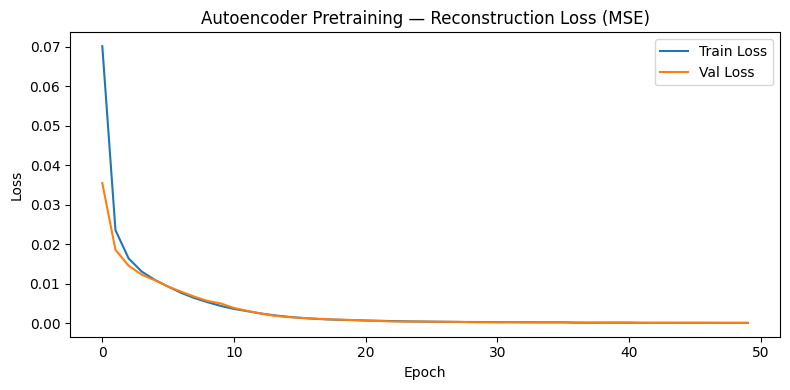

In [ ]:
def build_resnet_autoencoder(input_dim, latent_dim=32, resnet_units=[128, 64]):
    inputs = keras.Input(shape=(input_dim,), name='ae_input')
    x = resnet_block(inputs, resnet_units[0])
    x = resnet_block(x,      resnet_units[1])
    z = layers.Dense(latent_dim, activation='relu', name='latent_z')(x)
    x_dec = layers.Dense(resnet_units[1], activation='relu')(z)
    x_dec = layers.Dense(resnet_units[0], activation='relu')(x_dec)
    reconstruction = layers.Dense(input_dim, activation='linear', name='reconstruction')(x_dec)

    autoencoder = Model(inputs, reconstruction, name='resnet_autoencoder')
    encoder     = Model(inputs, z,              name='resnet_encoder')
    return autoencoder, encoder


LATENT_DIM    = 32
RESNET_UNITS  = [128, 64]
AE_EPOCHS     = 50
AE_BATCH_SIZE = 64

autoencoder, encoder = build_resnet_autoencoder(
    input_dim=input_dim, latent_dim=LATENT_DIM, resnet_units=RESNET_UNITS
)

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse'
)
autoencoder.summary()

ae_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

ae_history = autoencoder.fit(
    X_train_sm, X_train_sm,
    validation_data=(X_test_fw, X_test_fw),
    epochs=AE_EPOCHS, batch_size=AE_BATCH_SIZE,
    callbacks=ae_callbacks, verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(ae_history.history['loss'],     label='Train Loss')
plt.plot(ae_history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Pretraining — Reconstruction Loss (MSE)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
# Extract latent representations Z from the pretrained encoder
Z_train = encoder.predict(X_train_sm, verbose=0)
Z_test  = encoder.predict(X_test_fw,  verbose=0)

print(f'Dimensionality reduced: {input_dim} → {LATENT_DIM}')
print('Z_train shape:', Z_train.shape)


Dimensionality reduced: 29 → 32
Z_train shape: (17900, 32)


## Stage 3 — Dense Classifier on Latent Space

The latent features produced by the autoencoder are fed directly into a dense classifier.
This keeps the pipeline simpler and removes the LSTM while still using the learned compressed representation.

In [ ]:
y_train_cat = to_categorical(y_train_sm, num_classes=n_classes)
y_test_cat  = to_categorical(y_test,     num_classes=n_classes)

print('Latent input shape:', Z_train.shape)
print('y_train_cat shape:', y_train_cat.shape)


LSTM input shape: (17900, 32, 1)   →  [batch, timesteps=32, features=1]
y_train_cat shape: (17900, 5)


## Cheetah Algorithm — Hyperparameter Optimization

The **Cheetah Optimization Algorithm** searches the hyperparameter space with two phases:
- **Exploration:** random search across the space
- **Exploitation:** narrow to promising regions

This is simulated with a small candidate grid: try each configuration, keep the best one by validation accuracy.

In [ ]:
def build_dense_classifier(latent_dim, n_classes, hidden_units=64, dropout_rate=0.3):
    inputs = keras.Input(shape=(latent_dim,), name='dense_input')
    x = layers.Dense(hidden_units, activation='relu', name='dense_1')(inputs)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(hidden_units // 2, activation='relu', name='dense_2')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(32, activation='relu', name='dense_head')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(n_classes, activation='softmax', name='predictions')(x)
    return Model(inputs, outputs, name='dense_classifier')


candidate_configs = [
    {'hidden_units': 64,  'dropout': 0.2, 'lr': 1e-3, 'batch': 32},
    {'hidden_units': 128, 'dropout': 0.3, 'lr': 1e-3, 'batch': 64},
    {'hidden_units': 64,  'dropout': 0.3, 'lr': 5e-4, 'batch': 32},
    {'hidden_units': 128, 'dropout': 0.2, 'lr': 5e-4, 'batch': 64},
]

best_val_acc = 0
best_config  = None
best_history = None
best_model   = None

for i, cfg in enumerate(candidate_configs):
    print(f'Config {i+1}/{len(candidate_configs)}: {cfg}')
    model = build_dense_classifier(
        latent_dim=LATENT_DIM, n_classes=n_classes,
        hidden_units=cfg['hidden_units'], dropout_rate=cfg['dropout']
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg['lr']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        Z_train, y_train_cat,
        validation_data=(Z_test, y_test_cat),
        epochs=80, batch_size=cfg['batch'],
        verbose=0
    )
    val_acc = max(history.history['val_accuracy'])
    print(f'  → Best val accuracy: {val_acc:.4f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_config  = cfg
        best_history = history
        best_model   = model

print(f'\nBest config: {best_config}')
print(f'Best val accuracy: {best_val_acc:.4f}')


Config 1/4: {'lstm_units': 64, 'dropout': 0.2, 'lr': 0.001, 'batch': 32}
  → Best val accuracy: 0.7031
Config 2/4: {'lstm_units': 128, 'dropout': 0.3, 'lr': 0.001, 'batch': 64}
  → Best val accuracy: 0.7138
Config 3/4: {'lstm_units': 64, 'dropout': 0.3, 'lr': 0.0005, 'batch': 32}
  → Best val accuracy: 0.7081
Config 4/4: {'lstm_units': 128, 'dropout': 0.2, 'lr': 0.0005, 'batch': 64}
  → Best val accuracy: 0.7131

Best config: {'lstm_units': 128, 'dropout': 0.3, 'lr': 0.001, 'batch': 64}
Best val accuracy: 0.7138


## Training Curves

Accuracy and loss curves for the best configuration found.

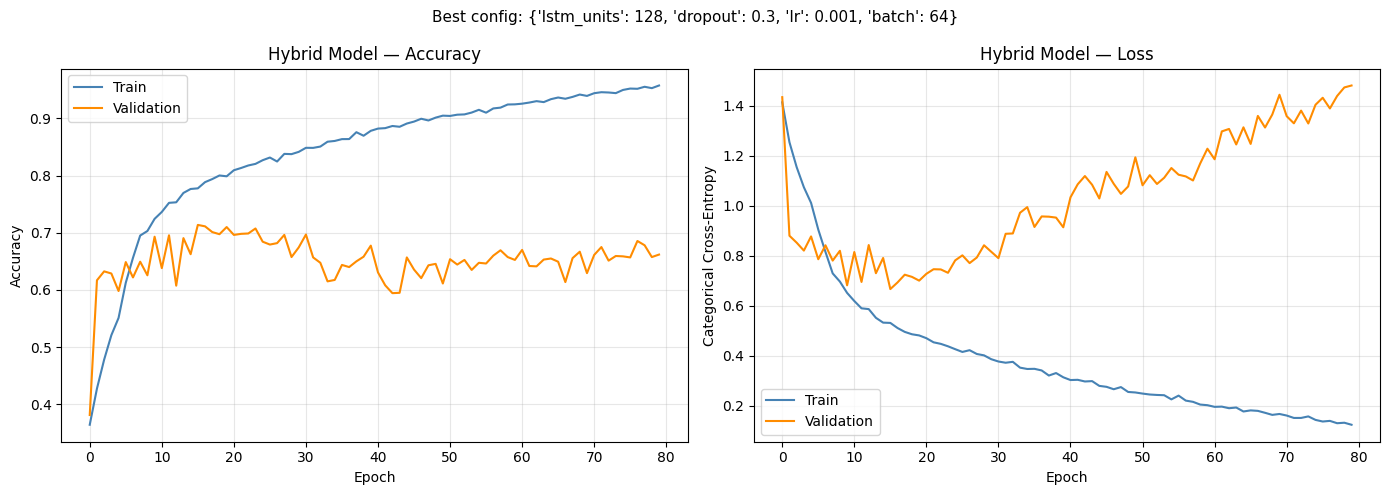

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(best_history.history['accuracy'],     label='Train',      color='steelblue')
axes[0].plot(best_history.history['val_accuracy'], label='Validation', color='darkorange')
axes[0].set_title('Hybrid Model — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(best_history.history['loss'],     label='Train',      color='steelblue')
axes[1].plot(best_history.history['val_loss'], label='Validation', color='darkorange')
axes[1].set_title('Hybrid Model — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Categorical Cross-Entropy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'Best config: {best_config}', fontsize=11)
plt.tight_layout(); plt.show()


## Evaluation

We evaluate with the same metrics as the paper: Accuracy, Precision, Recall, F1-Score, and AUC-ROC.

In [ ]:
y_pred_proba = best_model.predict(Z_test, verbose=0)
y_pred_fw    = np.argmax(y_pred_proba, axis=1)
fw_labels    = label_encoder.classes_

fw_acc       = accuracy_score(y_test, y_pred_fw)
fw_precision = precision_score(y_test, y_pred_fw, average='weighted', zero_division=0)
fw_recall    = recall_score(   y_test, y_pred_fw, average='weighted', zero_division=0)
fw_f1        = f1_score(       y_test, y_pred_fw, average='weighted', zero_division=0)

try:
    fw_auc = roc_auc_score(
        to_categorical(y_test, n_classes), y_pred_proba,
        multi_class='ovr', average='weighted'
    )
except Exception:
    fw_auc = float('nan')

print('=' * 45)
print('  HYBRID MODEL — PERFORMANCE METRICS')
print('=' * 45)
print(f'  Accuracy  : {fw_acc:.4f}  ({fw_acc*100:.2f}%)')
print(f'  Precision : {fw_precision:.4f}  ({fw_precision*100:.2f}%)')
print(f'  Recall    : {fw_recall:.4f}  ({fw_recall*100:.2f}%)')
print(f'  F1-Score  : {fw_f1:.4f}  ({fw_f1*100:.2f}%)')
print(f'  AUC-ROC   : {fw_auc:.4f}')
print('=' * 45)
print()
print('Detailed Classification Report:')
print(classification_report(y_test, y_pred_fw, target_names=fw_labels))

  HYBRID MODEL — PERFORMANCE METRICS
  Accuracy  : 0.6619  (66.19%)
  Precision : 0.6739  (67.39%)
  Recall    : 0.6619  (66.19%)
  F1-Score  : 0.6666  (66.66%)
  AUC-ROC   : 0.8419

Detailed Classification Report:
              precision    recall  f1-score   support

           A       0.84      0.79      0.81       895
           B       0.48      0.55      0.51       442
           C       0.47      0.43      0.45       211
           D       0.34      0.40      0.37        45
        Fail       0.00      0.00      0.00         7

    accuracy                           0.66      1600
   macro avg       0.43      0.43      0.43      1600
weighted avg       0.67      0.66      0.67      1600



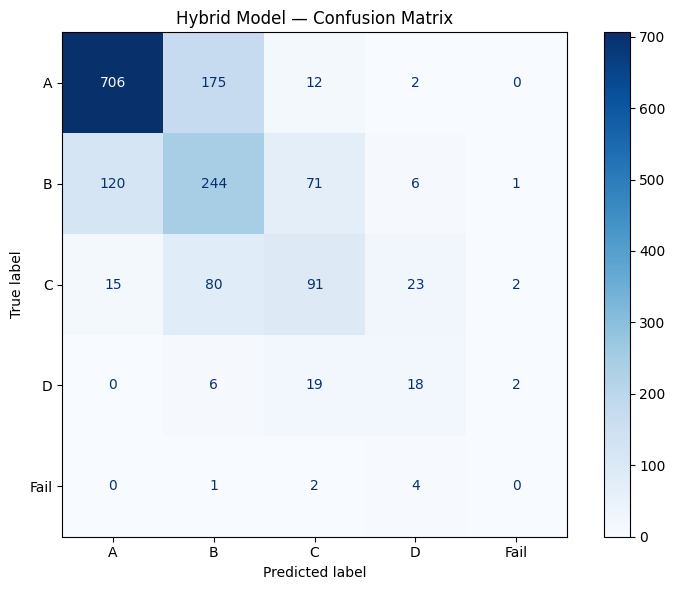

In [ ]:
cm_fw   = confusion_matrix(y_test, y_pred_fw)
disp_fw = ConfusionMatrixDisplay(confusion_matrix=cm_fw, display_labels=fw_labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp_fw.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Hybrid Model — Confusion Matrix')
plt.tight_layout(); plt.show()

## Baseline Comparison

Comparison against Logistic Regression and other baselines.

                          Accuracy Precision  Recall F1-Score AUC-ROC
Model                                                                
Logistic Regression         0.7625    0.7480  0.7625   0.7498  0.9195
Random Forest               0.7250    0.7030  0.7250   0.7035  0.8944
SVM                         0.7238    0.6912  0.7238   0.7049  0.9015
★ Hybrid (ResNet+AE+LSTM)   0.6619    0.6739  0.6619   0.6666  0.8419


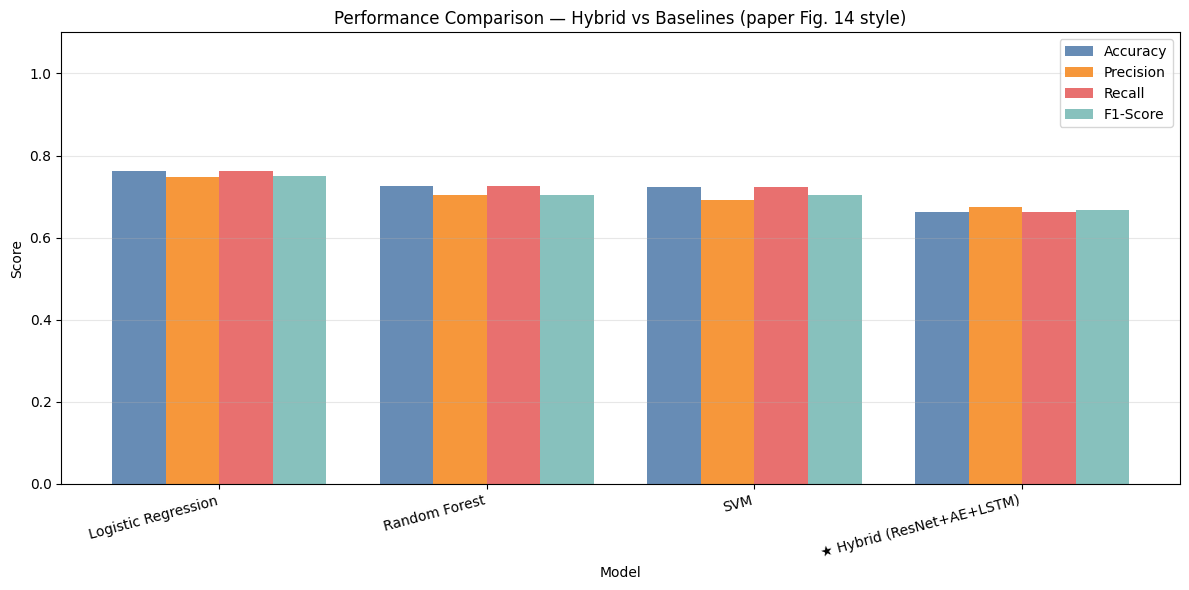

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

baselines = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
}

results = []
for name, clf in baselines.items():
    clf.fit(X_train_fw, y_train)
    yp       = clf.predict(X_test_fw)
    yp_proba = clf.predict_proba(X_test_fw)
    try:
        auc_b = roc_auc_score(to_categorical(y_test, n_classes), yp_proba,
                              multi_class='ovr', average='weighted')
    except Exception:
        auc_b = float('nan')
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score( y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted', zero_division=0),
        'Recall':    recall_score(   y_test, yp, average='weighted', zero_division=0),
        'F1-Score':  f1_score(       y_test, yp, average='weighted', zero_division=0),
        'AUC-ROC':   auc_b,
    })

results.append({
    'Model':     '★ Hybrid (ResNet+AE+LSTM)',
    'Accuracy':  fw_acc, 'Precision': fw_precision,
    'Recall':    fw_recall, 'F1-Score': fw_f1, 'AUC-ROC': fw_auc,
})

df_results = pd.DataFrame(results).set_index('Model')
print(df_results.map(lambda x: f'{x:.4f}').to_string())

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x      = np.arange(len(df_results))
width  = 0.2
colors = ['#4c78a8', '#f58518', '#e45756', '#72b7b2']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    ax.bar(x + i * width, df_results[metric].values, width,
           label=metric, color=color, alpha=0.85)

ax.set_xlabel('Model'); ax.set_ylabel('Score')
ax.set_title('Performance Comparison — Hybrid vs Baselines (paper Fig. 14 style)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_results.index.tolist(), rotation=15, ha='right')
ax.set_ylim(0, 1.1); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Save and reload the model

- `preprocessor_fw`: Transforms input variables.
- `encoder`: Converts data to the latent representation.
- `best_model`: Classifies over the latent representation.
- `label_encoder`: Retrieves original labels


In [2]:
from pathlib import Path
import joblib

artifact_dir = Path("artifacts")
artifact_dir.mkdir(exist_ok=True)

best_model.save(artifact_dir / "hybrid_model.keras")
encoder.save(artifact_dir / "hybrid_encoder.keras")
joblib.dump(preprocessor_fw, artifact_dir / "hybrid_preprocessor.joblib")
joblib.dump(label_encoder, artifact_dir / "label_encoder.joblib")
joblib.dump(best_config, artifact_dir / "best_config.joblib")

print(f"Model artifacts saved in: {artifact_dir.resolve()}")
print("- hybrid_model.keras")
print("- hybrid_encoder.keras")
print("- hybrid_preprocessor.joblib")
print("- label_encoder.joblib")
print("- best_config.joblib")

NameError: name 'best_model' is not defined

Baseline accuracy: 0.661875
Permutation importances (drop in accuracy):
Hours_Studied                 0.1369
Stress_Level                  0.0506
Previous_GPA                  0.0481
Attendance                    0.0431
Tutoring_Sessions_Per_Week    0.0400
Exam_Anxiety_Score            0.0350
Sleep_Hours                   0.0119
Diet_Quality                  0.0088
Part_Time_Job                 0.0056
Extracurricular               0.0006
Study_Method                  0.0006
Gender                       -0.0006
Age                          -0.0019
Screen_Time                  -0.0044
Family_Income_Level          -0.0081
Internet_Quality             -0.0100
dtype: float64


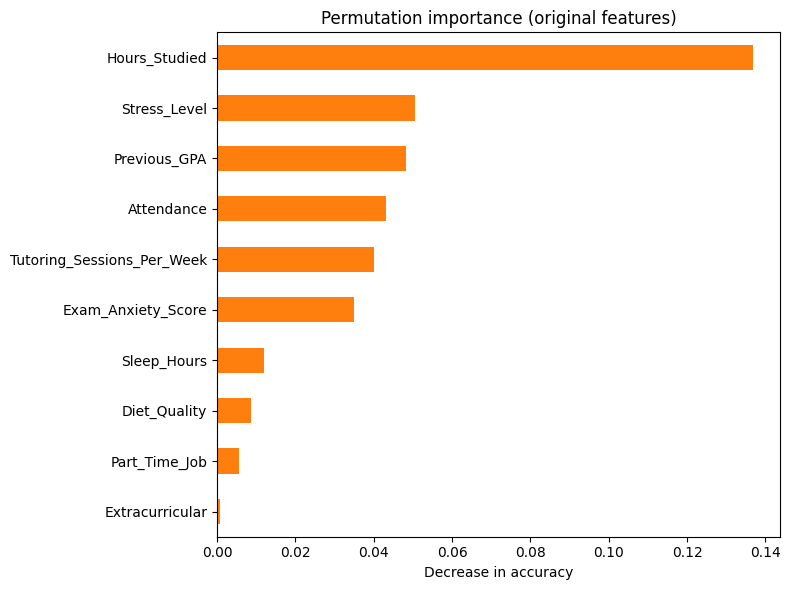

In [13]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from tensorflow import keras
import matplotlib.pyplot as plt

artifact_dir = Path('artifacts')
try:
    preprocessor = joblib.load(artifact_dir / 'hybrid_preprocessor.joblib')
    label_encoder = joblib.load(artifact_dir / 'label_encoder.joblib')
    encoder = keras.models.load_model(artifact_dir / 'hybrid_encoder.keras', compile=False)
    model = keras.models.load_model(artifact_dir / 'hybrid_model.keras', compile=False)
except Exception as e:
    print('Error cargando artefactos:', e)
    raise

def predict_labels_from_df(X_df):
    X_proc = X_df.copy()
    if 'Student_ID' in X_proc.columns:
        X_proc = X_proc.drop(columns=['Student_ID'])
    X_proc = X_proc.reindex(columns=X.columns)
    X_proc = X_proc.fillna(X.mode().iloc[0])
    X_fw = preprocessor.transform(X_proc)
    Z = encoder.predict(X_fw, verbose=0)
    Z_seq = Z.reshape(Z.shape[0], Z.shape[1], 1)
    proba = model.predict(Z_seq, verbose=0)
    preds = np.argmax(proba, axis=1)
    return preds, proba

y_true = y_test
baseline_preds, baseline_proba = predict_labels_from_df(X_test)
baseline_score = accuracy_score(y_true, baseline_preds)
print('Baseline accuracy:', baseline_score)

importances = {}
for col in X.columns:
    X_perm = X_test.copy()
    X_perm[col] = np.random.permutation(X_perm[col].values)
    preds_perm, _ = predict_labels_from_df(X_perm)
    score_perm = accuracy_score(y_true, preds_perm)
    importances[col] = baseline_score - score_perm

imp_series = pd.Series(importances).sort_values(ascending=False)
print('Permutation importances (drop in accuracy):')
print(imp_series.round(4))

imp_series.head(10).plot(kind='barh', figsize=(8,6), color='C1')
plt.gca().invert_yaxis(); plt.xlabel('Decrease in accuracy'); plt.title('Permutation importance (original features)'); plt.tight_layout(); plt.show()
